In [1]:
# Installing Dependencies
%pip install sympy casadi matplotlib scipy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sympy
import scipy.integrate
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
from scipy.stats import chi2
import numpy as np
import math as math

In [3]:
# Defining Class called RoverModel
# We like Object Orientedness it keeps things clean
class RoverModel:
    def __init__(self):
        # whatever we need to define abt the rover goes here

        self.t  = sympy.symbols("t") # time
        self.Delta_t = sympy.symbols("dt") # Time Step
        self.T = sympy.symbols("T") # simulaion duration
        self.r_fig8 = sympy.symbols("r_{fig8}") # Radius of each lobe of the figure-eight    
        self.T_fig8 = sympy.symbols("T_{fig8}")
        self.T_lobe = sympy.symbols("T_{lobe}")
        self.GPS_rate = sympy.symbols("GPS Rate")

        # state
        x = sympy.symbols("x")
        y = sympy.symbols("y")
        theta = sympy.symbols("theta")
        self.x = sympy.Matrix([x, y, theta])

        # input
        self.v_ref = sympy.symbols("v_{ref}")
        self.omega_turn = sympy.symbols("omega_{turn}")
        # input (as a function of time)
        omega_ref = self.omega_ref_expr()
        self.u = sympy.Matrix([self.v_ref, omega_ref]) ## ASK ABT THIS

        # Covariance
        self.P = sympy.MatrixSymbol("P", 3, 3)

        # Process Noise (Body Frame Velocity noise)
        w_v = sympy.symbols("w_v")  
        w_omega = sympy.symbols("w_omega")
        self.w = sympy.Matrix([w_v, w_omega])
        self.n_k = sympy.Matrix([w_v, 0, w_omega])

        # Measurement Noise
        v_x = sympy.symbols("v_x")
        v_y = sympy.symbols("v_y")
        self.v = sympy.Matrix([v_x, v_y])

        # std deviations
        self.sigma_v = sympy.symbols("sigma_v")
        self.sigma_omega = sympy.symbols(r"\sigma_{omega}")
        self.sigma_GPS = sympy.symbols(r"\sigma_{GPS}")

        # Noise Covariances Matrices

        # Process Covariance
        self.Q_body = sympy.Matrix.diag(self.sigma_v**2,  self.sigma_omega**2) 
        self.Q_body_3 = sympy.Matrix.diag(self.sigma_v**2, 0, self.sigma_omega**2) 

        ## Taking Q_body as 2x2 Matrix
        # Measurement Covariance
        self.R = sympy.Matrix.diag(self.sigma_GPS**2, self.sigma_GPS**2)



    # Since omega_ref is a function of time, 
    # we define a fn as below and use it inside dynamics

    def omega_ref_expr(self):
        tau = sympy.Mod(self.t, self.T_fig8)
        return sympy.Piecewise(
            (self.omega_turn, tau < self.T_lobe),
            (-self.omega_turn, True)
        )
    

    def dynamics(self):
        x = self.x[0]
        y = self.x[1]
        theta = self.x[2]
        w_v = self.w[0]
        w_omega = self.w[1]
        cos = sympy.cos
        sin = sympy.sin
        v_ref = self.u[0]
        omega_ref = self.u[1]
        x_dot = sympy.Matrix([
            (v_ref + w_v)*cos(theta),
            (v_ref + w_v)*sin(theta),
            (omega_ref + w_omega)
        ])

        return x_dot
    
    # Discrete Dynamics
    
    def discrete_dynamics(self):
        x, y, theta = self.x
        v_ref = self.v_ref
        omega_ref = self.omega_ref_expr()
        phi = omega_ref * self.Delta_t
        travel = self.Delta_t * v_ref * sympy.sinc(phi / 2)
        theta_mid = theta + phi / 2

        return sympy.Matrix([
            x + travel * sympy.cos(theta_mid),
            y + travel * sympy.sin(theta_mid),
            theta + phi
        ])

    # Reference Twist
    def reference_twist(self):
        v_ref = self.v_ref
        omega_ref = self.omega_ref_expr()
        twist_ref = sympy.Matrix([v_ref, 0, omega_ref])
        return twist_ref
    
    def gps_measurement(self):
        v_x = self.v[0]
        v_y = self.v[1]
        x = self.x[0]
        y = self.x[1]
        return sympy.Matrix([x + v_x, y + v_y])
    
    
model =  RoverModel()

# Helper Functions (Lie Group)

In [4]:
def so2_wedge(theta):
  theta_wedge = [[0, -theta]
                 ,[theta, 0]];
  return(np.array(theta_wedge))

def so2_vee(Omega):
  theta = np.array(Omega[1,0]);
  return(theta)

def so2_exp(theta):
  R_theta = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]]);
  return(R_theta)

def so2_log(R):
  theta = np.arctan2(R[1,0], R[0,0]);
  return(theta) # returns theta wrapped in -pi to pi


In [5]:
def se2_wedge(xi):
    xi = np.asarray(xi).reshape(3,)
    vx, vy, w = xi[0], xi[1], xi[2]

    Xi = np.array([
        [0.0, -w,  vx],
        [w,   0.0, vy],
        [0.0, 0.0, 0.0]
    ], dtype=float)
    return Xi


def se2_vee(Xi):
    Xi = np.asarray(Xi)
    assert Xi.shape == (3, 3), "Xi must be 3x3"

    vx = Xi[0, 2]
    vy = Xi[1, 2]
    w  = Xi[1, 0]
    return np.array([vx, vy, w], dtype=float)

In [6]:
def se2_log(X, eps=1e-6):

    X = np.asarray(X)
    assert X.shape == (3, 3), "X must be 3x3"

    R = X[0:2, 0:2]
    t = X[0:2, 2]

    # Angle from rotation matrix (same as your so2_log)
    w = np.arctan2(R[1, 0], R[0, 0])

    J = np.array([[0, -1],
                  [1,  0]])
    JT = -J  # [[0,1],[-1,0]] which appears in V_inv

    if abs(w) < eps:
        # We need V_inv(w) ≈ I - (w/2)J + (w^2/12)I - (w^4/720)I + ... (5 terms total)
        # Start from (w/2)cot(w/2) series: 1 - w^2/12 - w^4/720 + ...
        a = 1.0 - (w**2)/12.0 - (w**4)/720.0   # 3 terms for the scalar
        b = w/2.0                               # 1 term for the skew part

        V_inv = a * np.eye(2) + b * JT
    else:
        # Closed-form: (w/2)cot(w/2) I + (w/2) * JT
        a = (w / 2.0) / np.tan(w / 2.0)  # (w/2)cot(w/2)
        V_inv = a * np.eye(2) + (w / 2.0) * JT

    v = V_inv @ t
    return np.array([v[0], v[1], w], dtype=float)


In [7]:
def se2_exp(xi, eps=1e-6):

    xi = np.asarray(xi).reshape(3,)
    vx, vy, w = xi
    v = np.array([vx, vy])

    J = np.array([[0, -1],
                  [1,  0]])

    # Rotation
    R = so2_exp(w)

    # Translation coupling matrix V
    if abs(w) < eps:
        # 5-term Taylor series
        V = (
            np.eye(2)
            + (w / 2.0) * J
            + (w**2 / 6.0) * (J @ J)
            + (w**3 / 24.0) * (J @ J @ J)
            + (w**4 / 120.0) * (J @ J @ J @ J)
        )
    else:
        V = (np.sin(w) / w) * np.eye(2) + ((1 - np.cos(w)) / w) * J

    t = V @ v

    X = np.eye(3)
    X[0:2, 0:2] = R
    X[0:2, 2] = t

    return X


# PROBLEM 1
The Banana Distribution

# a. Simulate the unicycle

We won't be using any Sympy for Monte Carlo, it would be all numeric calculations

In [8]:
dt = 0.1
T = 35
v_ref = 2
omega_turn = 0.4
T_fig8 = 10*math.pi
T_lobe = 2*math.pi/omega_turn

N = 1000 # Number of Trials for Monte Carlo simulation

def trajectories(sigma_v, sigma_omega):

    def omega_ref_expr(tk):
        tau = tk % T_fig8
        if (tau < T_lobe):
            omega_ref = omega_turn
        else:
            omega_ref = -omega_turn
        return omega_ref

    all_poses = []
    all_states = []
    # Outter Loop for 1000 such 8 fig trajectories
    for j in range(N):
        # initial pose
        X = np.eye(3) # X0
        poses = [X.copy()]
        states = [(0, 0, 0)]  #initial state
        tk = 0

    # Inner Loop for 8 fig trajectory of 35 secs
        for i in range(int(T/dt)): # Number of time steps we calculate poses for
            tk = dt * i
            w_v = np.random.normal(0,sigma_v)
            w_omega = np.random.normal(0, sigma_omega) # TO NOT draw from one constant bias

            v = v_ref + w_v
            omega = omega_ref_expr(tk) + w_omega

            twist = np.array([v, 0, omega])
            X =  X @ se2_exp(twist * dt)
            poses.append(X.copy())


            x_i = X[0, 2]
            y_i = X[1, 2]
            theta_i = math.atan2(X[1, 0], X[0, 0]) # Collecting x, y, theta

            state_i = [x_i, y_i, theta_i] # state
            states.append(state_i.copy())

        all_poses.append(poses.copy())
        all_states.append(states.copy())
    all_poses = np.array(all_poses)
    all_states = np.array(all_states)

    return(all_states)

In [9]:
all_states_ref = trajectories(sigma_v = 0, sigma_omega= 0) # determinsitic 

# b.  Plot the distribution

In [10]:
def scatter_plot(all_states_noisy, all_states_ref, sigma_v, sigma_omega):

    x_noisy = all_states_noisy[:, -1, 0]
    y_noisy = all_states_noisy[:, -1, 1]
    theta_noisy = all_states_noisy[:, -1, 2]

    x_nom = all_states_ref[0, :, 0]
    y_nom = all_states_ref[0, :, 1]
    theta_nom = all_states_ref[0, :, 2]

    # For arrow head of nominal trajectory
    x_end = x_nom[-1]
    y_end = y_nom[-1]
    th_end = theta_nom[-1]

    plt.figure()

    # Monte Carlo endpoints (banana)
    plt.scatter(x_noisy, y_noisy, s=10, alpha=0.4)

    # Nominal trajectory
    plt.plot(x_nom, y_nom, color='red', linewidth=2)

    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"sigma_v = {sigma_v}, sigma_omega = {sigma_omega}")
    plt.axis("equal")
    plt.grid(True)

    L = 0.6

    plt.quiver(x_end, y_end, L*np.cos(th_end), L*np.sin(th_end),
            color='black', scale_units='xy', scale=1,
        width=0.004, headwidth=6, headlength=7,
        zorder=5)


    idx = np.arange(0, len(x_noisy), 5)   # every 5th point, to avoid clutter

    plt.quiver(
        x_noisy[idx],
        y_noisy[idx],
        L * np.cos(theta_noisy[idx]),
        L * np.sin(theta_noisy[idx]),
        angles='xy',
        scale_units='xy',
        scale=1,
        color='yellow',
        alpha=0.6
    )

In [11]:
all_states_noisy = trajectories(sigma_v = 0.01, sigma_omega= 0.05)

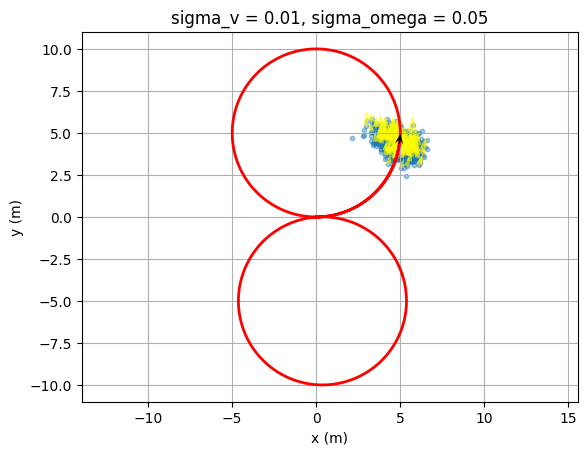

In [12]:
scatter_plot(all_states_noisy, all_states_ref, sigma_v = 0.01, sigma_omega= 0.05)

In [13]:
all_states_noisy = trajectories(sigma_v = 1, sigma_omega= 0.05)

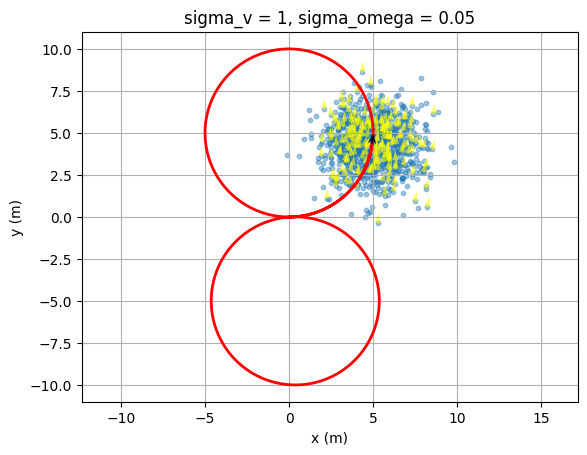

In [14]:
scatter_plot(all_states_noisy, all_states_ref, sigma_v = 1, sigma_omega= 0.05)

# c. Fit a Gaussian

In [15]:
def mu_sig(X):
    XY = X[:, :2] # (x, y); no theta

    mu_xy = np.mean(XY, axis=0) 

    Sigma_xy = np.cov(XY.T) 
    return mu_xy, Sigma_xy 


In [16]:
def gaussian_fitting(all_states_noisy, sigma_v, sigma_omega):
    mu_xy, Sigma_xy = mu_sig(all_states_noisy[:, -1, :] )
    # mu_xy, Sigma_xy # p_bar # S; Non Zero Off Diag terms
    scatter_plot(all_states_noisy, all_states_ref, sigma_v, sigma_omega)
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(Sigma_xy)

    # Sort (largest first)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Angle of ellipse
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])

    # 3-sigma scaling
    k = 3

    # Ellipse radii
    width = 2 * k * np.sqrt(eigvals[0])
    height = 2 * k * np.sqrt(eigvals[1])

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, 100)
    ellipse = np.array([width/2 * np.cos(t), height/2 * np.sin(t)])

    # Rotate ellipse
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    ellipse_rot = R @ ellipse

    # Shift to mean
    ellipse_rot[0, :] += mu_xy[0]
    ellipse_rot[1, :] += mu_xy[1]

    # Plot
    plt.plot(ellipse_rot[0, :], ellipse_rot[1, :],
            color='black', linewidth=2, label='3σ Gaussian fit')
    plt.scatter(mu_xy[0], mu_xy[1], color='red', s=50, label='Mean')
    plt.legend()

In [17]:
all_states_noisy = trajectories(sigma_v = 1, sigma_omega= 0.05)

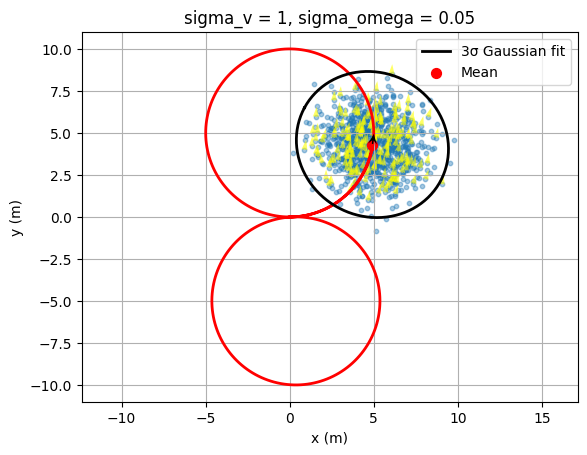

In [18]:
gaussian_fitting(all_states_noisy,sigma_v=1, sigma_omega=0.05)

- sigma_v = 0.1, sigma_omega = 0.05

In [19]:
all_states_noisy = trajectories(sigma_v = 0.1, sigma_omega= 0.05)

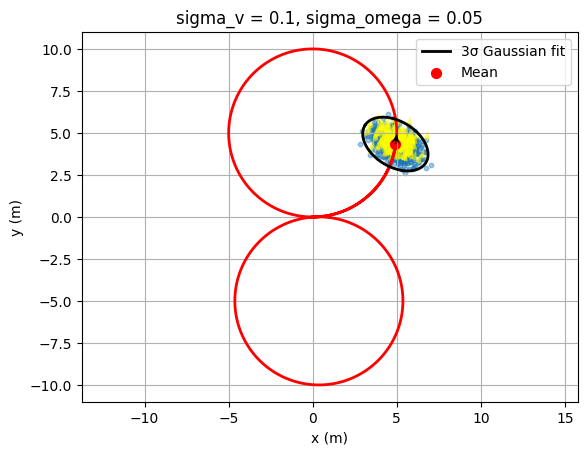

In [20]:
gaussian_fitting(all_states_noisy, sigma_v = 0.1, sigma_omega= 0.05)

- sigma_v = 0.01, sigma_omega= 0.2

In [21]:
all_states_noisy = trajectories(sigma_v = 0.01, sigma_omega= 0.2)

In [22]:
gaussian_fitting(all_states_noisy, sigma_v=0.01, sigma_omega=0.2)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[1], line 1
----> 1 gaussian_fitting(all_states_noisy, sigma_v, sigma_omega)

NameError: name 'sigma_v' is not defined


NameError: name 'sigma_v' is not defined

# d. Characterize the distribution

It is because Gaussian Noise is injected in the Body Frame and then (x, y) end point positions are in the world frame. This Body Frame Velocity -> World Frame mapping is Non Linear and Time varying. Gaussian Fails to capture it because its a Linear Estimator.


time k: there's a heading direction and forward velocity at time at time 


time k+1: heading slightly different -> push in a new direction


over many steps leads to error tracing an arc.

# e. Intermediate Snapshots

I'll do this for two cases, 
1. sigma_v = 1, sigma_omega = 0.05
2. sigma_v = 0.01, sigma_omega = 0.2

1. sigma_v = 1, sigma_omega = 0.05


In [131]:
all_states_noisy = trajectories(sigma_v = 1, sigma_omega= 0.05)

In [132]:
def snapshot_plots(all_states_noisy, all_states_ref, dt, sigma_v, sigma_omega):
    snapshot_times = [5, 15, 30]
    snapshot_indices = [int(t / dt) for t in snapshot_times]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    for ax, t_snap, k in zip(axes, snapshot_times, snapshot_indices):
        x_snap = all_states_noisy[:, k, 0]
        y_snap = all_states_noisy[:, k, 1]
        theta_snap = all_states_noisy[:, k, 2]

        x_nom = all_states_ref[0, :k+1, 0]
        y_nom = all_states_ref[0, :k+1, 1]

        ax.scatter(x_snap, y_snap, s=10, alpha=0.4)
        ax.plot(x_nom, y_nom, color="red", linewidth=2)

        idx = np.arange(0, len(x_snap), 20)
        L = 0.4
        ax.quiver(
            x_snap[idx],
            y_snap[idx],
            L * np.cos(theta_snap[idx]),
            L * np.sin(theta_snap[idx]),
            angles="xy",
            scale_units="xy",
            scale=1,
            color="yellow",
            alpha=0.6
        )

        ax.set_title(f"t = {t_snap} s")
        ax.set_aspect("equal")
        ax.grid(True)
        ax.set_xlabel("x (m)")

    axes[0].set_ylabel("y (m)")
    fig.suptitle(f"Intermediate snapshots: sigma_v = {sigma_v}, sigma_omega = {sigma_omega}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

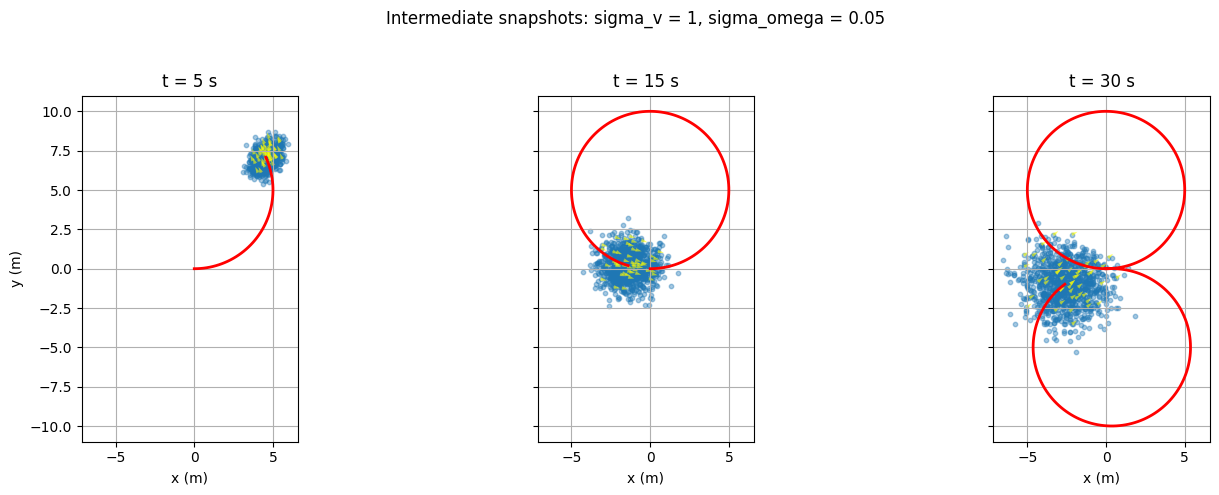

In [133]:
snapshot_plots(all_states_noisy, all_states_ref, dt, sigma_v = 1, sigma_omega= 0.05)

This clearly refelects the error accumalating over time point which I was making in part d.

2. sigma_v = 0.01, sigma_omega = 0.2

In [136]:
all_states_noisy = trajectories(sigma_v = 0.01, sigma_omega= 0.2)

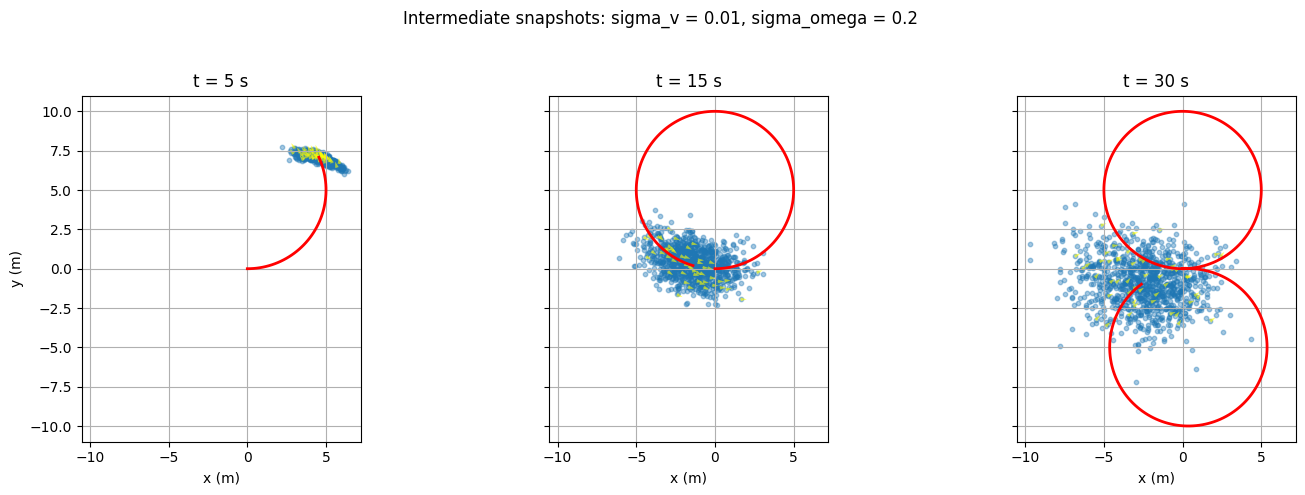

In [138]:
snapshot_plots(all_states_noisy, all_states_ref, dt, sigma_v = 0.01, sigma_omega= 0.2)

Same here, the "banananess" of the curve is increasing as time is increasing

# f. Lie algebra Gaussian fit

In [ ]:
def poses(sigma_v, sigma_omega):

    def omega_ref_expr(tk):
        tau = tk % T_fig8
        if (tau < T_lobe):
            omega_ref = omega_turn
        else:
            omega_ref = -omega_turn
        return omega_ref

    all_poses = []

    # Outter Loop for 1000 such 8 fig trajectories
    for j in range(N):
        # initial pose
        X = np.eye(3) # X0
        poses = [X.copy()]

        tk = 0

    # Inner Loop for 8 fig trajectory of 35 secs
        for i in range(int(T/dt)): # Number of time steps we calculate poses for
            tk = dt * i
            w_v = np.random.normal(0,sigma_v)
            w_omega = np.random.normal(0, sigma_omega) # TO NOT draw from one constant bias

            v = v_ref + w_v
            omega = omega_ref_expr(tk) + w_omega

            twist = np.array([v, 0, omega])
            X =  X @ se2_exp(twist * dt)
            poses.append(X.copy())

        all_poses.append(poses.copy())

    all_poses = np.array(all_poses)

    return(all_poses)

In [ ]:
all_poses_nom = poses(sigma_v = 0, sigma_omega = 0) # Nominal Poses

In [147]:
X_T_nom = all_poses_nom[-1, -1]
X_T_nom

array([[ 0.13042371, -0.99145835,  4.92546217],
       [ 0.99145835,  0.13042371,  4.34665837],
       [ 0.        ,  0.        ,  1.        ]])

In [ ]:
def mu_sig_twist(X):

    E_bar = np.mean(X, axis=0) 

    Sigma = np.cov(X.T) 
    return E_bar, Sigma

def LA_Gaussian_fit(sigma_v, sigma_omega):
    all_poses_noisy = poses(sigma_v, sigma_omega)
    X_i = all_poses_noisy[:, -1]
    # X_i.shape # 1000 End Poses for 1000 Monte Carlo Simulations
    error_twist = []
    for i in range(N):
        xi_err = (se2_log(np.linalg.inv(X_T_nom) @ X_i[i, :, :]))
        error_twist.append(xi_err)
    error_twist = np.array(error_twist)

    E_bar, Sigma = mu_sig_twist(error_twist)

    eps1 = error_twist[:, 0]
    eps2 = error_twist[:, 1]
    eps3 = error_twist[:, 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(eps1, eps2, s=10, alpha=0.4)
    axes[0].set_xlabel(r"$\epsilon_1$")
    axes[0].set_ylabel(r"$\epsilon_2$")
    axes[0].set_title(r"$\epsilon_1$-$\epsilon_2$ projection")
    axes[0].grid(True)

    axes[1].scatter(eps1, eps3, s=10, alpha=0.4)
    axes[1].set_xlabel(r"$\epsilon_1$")
    axes[1].set_ylabel(r"$\epsilon_3$")
    axes[1].set_title(r"$\epsilon_1$-$\epsilon_3$ projection")
    axes[1].grid(True)
    # --- Helper to draw 3-sigma ellipse ---
    def plot_ellipse(ax, mu, Sigma2D, color='black'):
        eigvals, eigvecs = np.linalg.eigh(Sigma2D)

        # sort eigenvalues
        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        # angle
        angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])

        # 3-sigma
        k = 3
        width = 2 * k * np.sqrt(eigvals[0])
        height = 2 * k * np.sqrt(eigvals[1])

        t = np.linspace(0, 2*np.pi, 100)
        ellipse = np.array([width/2 * np.cos(t), height/2 * np.sin(t)])

        R = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])

        ellipse_rot = R @ ellipse
        ellipse_rot[0, :] += mu[0]
        ellipse_rot[1, :] += mu[1]

        ax.plot(ellipse_rot[0, :], ellipse_rot[1, :], color=color, linewidth=2)


    # --- ε1-ε2 ellipse ---
    mu_12 = E_bar[[0, 1]]
    Sigma_12 = Sigma[np.ix_([0, 1], [0, 1])]
    plot_ellipse(axes[0], mu_12, Sigma_12)

    # --- ε1-ε3 ellipse ---
    mu_13 = E_bar[[0, 2]]
    Sigma_13 = Sigma[np.ix_([0, 2], [0, 2])]
    plot_ellipse(axes[1], mu_13, Sigma_13)

    # --- plot mean points ---
    axes[0].scatter(mu_12[0], mu_12[1], color='red', s=40)
    axes[1].scatter(mu_13[0], mu_13[1], color='red', s=40)
        
    return plt.tight_layout()

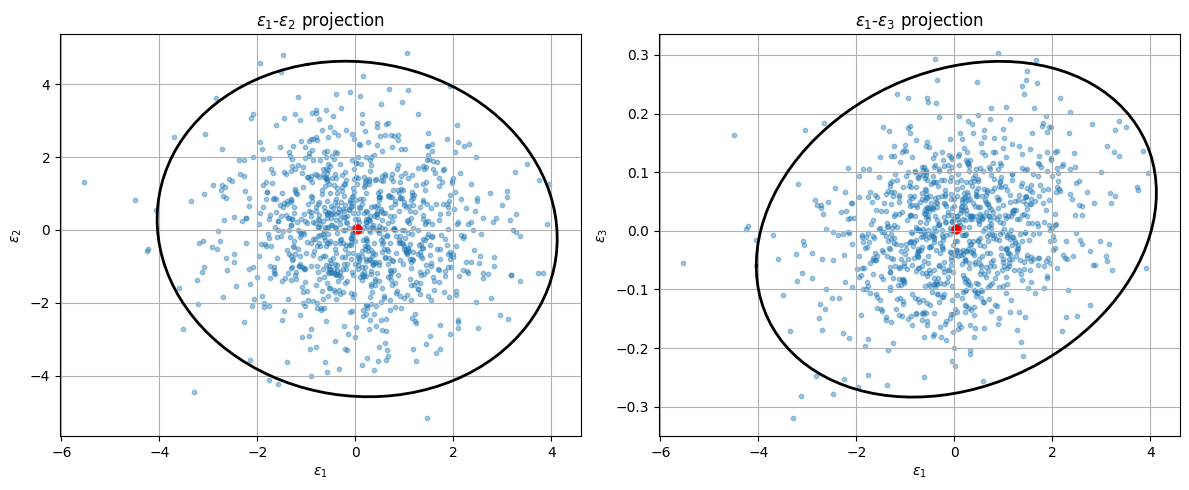

In [269]:
LA_Gaussian_fit(sigma_v= 1, sigma_omega= 0.05)

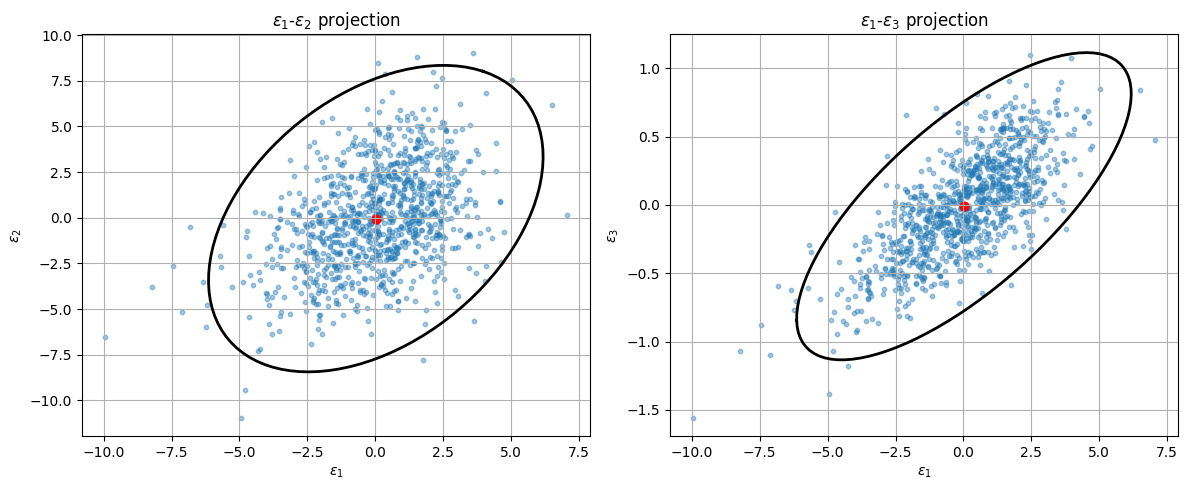

In [277]:
LA_Gaussian_fit(sigma_v= 0.01, sigma_omega= 0.2)

We observe a tilted Gaussian blob - approximately ellipsoidal when expressing body frame error in Lie Algebra (at final time) in frame of nominal trajectory.

The E1, E2 projection shows the structure of position uncertainty, while the E1, E3 projection reveals the coupling between heading and position errors. In particular, the strong correlation between E1 and E3
reflects how heading uncertainty accumulates and propagates into positional error during curved motion. This coupling is a key source of nonlinearity that is difficult to interpret in world-frame coordinates but becomes approximately linear in the Lie algebra representation. Hence the tilted Gausian blobs

# g. Exponentiate the ellipsoid boundary

3D Gaussian → ellipsoid, uses:
x=sinϕcosψ, y=sinϕsinψ, z=cosϕ

In [295]:
phi = np.linspace(0, np.pi, 30)
psi = np.linspace(0, 2*np.pi, 60)

Phi, Psi = np.meshgrid(phi, psi)
sphere = np.array([
    np.sin(Phi) * np.cos(Psi),
    np.sin(Phi) * np.sin(Psi),
    np.cos(Phi)
]) 

def Error_Twist(all_poses_noisy):
    X_i = all_poses_noisy[:, -1]
    # X_i.shape # 1000 End Poses for 1000 Monte Carlo Simulations
    error_twist = []
    for i in range(N):
        xi_err = (se2_log(np.linalg.inv(X_T_nom) @ X_i[i, :, :]))
        error_twist.append(xi_err)
    error_twist = np.array(error_twist)
    return error_twist

def Ellipsoid_bp(all_poses_noisy):
    error_twist = Error_Twist(all_poses_noisy)
    E_bar, Sigma = mu_sig_twist(error_twist)
    eigvals, eigvecs = np.linalg.eigh(Sigma)

    # Sort (largest to smallest)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Diagonal matrix D
    D = np.diag(eigvals)

    # V matrix
    V = eigvecs
    E_phi_psi = E_bar.reshape(3,1) + 3 * V @ np.sqrt(D) @ sphere.reshape(3, -1)
    X_phi_psi = []
    p_phi_psi = []
    for i in range(len(E_phi_psi[0])): # Grid Size
        pose = X_T_nom @ se2_exp(E_phi_psi[:, i])
        X_phi_psi.append(pose.copy())
        p_phi_psi.append([pose[0, 2], pose[1, 2]])
    X_phi_psi = np.array(X_phi_psi)
    p_phi_psi = np.array(p_phi_psi)
    return p_phi_psi


In [311]:
 def Ellipsoid_curve(all_states_noisy, all_poses_noisy, sigma_v, sigma_omega):  
    gaussian_fitting(all_states_noisy,sigma_v = 1, sigma_omega= 0.05) 
    p_phi_psi = Ellipsoid_bp(all_poses_noisy)
    x_curve = p_phi_psi[:, 0]
    y_curve = p_phi_psi[:, 1]
    plt.title(f"sigma_v = {sigma_v}, sigma_omega = {sigma_omega}")

    plt.plot(x_curve, y_curve, color='magenta', linewidth=2, label='Exp-mapped 3σ boundary')
    plt.legend()

In [314]:
sigma_v = 1
sigma_omega= 0.05
all_states_noisy = trajectories(sigma_v, sigma_omega)    
all_poses_noisy = poses(sigma_v, sigma_omega)

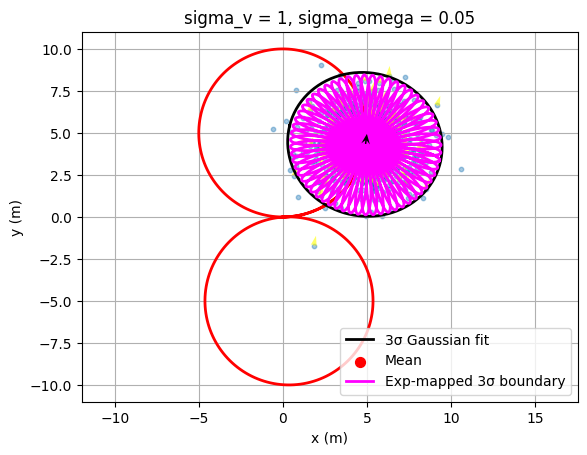

In [315]:
Ellipsoid_curve(all_states_noisy, all_poses_noisy, sigma_v = 1, sigma_omega = 0.05)

In [307]:
sigma_v = 0.01
sigma_omega= 0.2
all_states_noisy = trajectories(sigma_v, sigma_omega)    
all_poses_noisy = poses(sigma_v, sigma_omega)

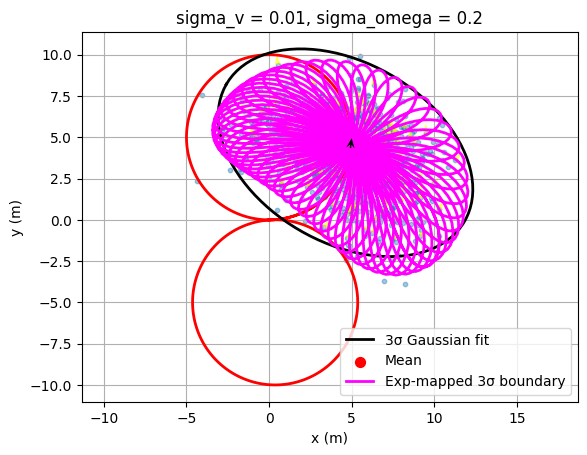

In [313]:
Ellipsoid_curve(all_states_noisy, all_poses_noisy, sigma_v= 0.01, sigma_omega = 0.2)

- iv) Discussion

The curvature arises because perturbations in the Lie algebra are applied in the body frame, and when exponentiated (for getting World Frame Coordinates), they are transported through the nonlinear kinematics of the unicycle model; involving terms like cos(theta), sin(theta). 

As a result, forward-velocity perturbations are rotated differently depending on heading error, producing a curved, banana-like distortion in the world frame.

Also, the banananess is more evident in sigma_omega = 0.2 and sigma_v =0.01, since for sigma_v = 1, sigma_omega = 0.05, the process noise in forward vel is comparable to v_nom ( = 1), the reference fwd velocity itself. 

# P2 - WORLD-FRAME EKF

In [19]:
def derive_EKF():

    f = model.dynamics()
    h = model.gps_measurement()

    F = f.jacobian(model.x)
    G = f.jacobian(model.w)
    H = h.jacobian(model.x)
    M = h.jacobian(model.v)


    ## I am setting the noise to 0 since 
    ## EKF Linearizes around the nominal trajectory
    F_nom = F.subs({
        model.w[0]: 0,
        model.w[1]: 0
    })

    G_nom = G.subs({
        model.w[0]: 0,
        model.w[1]: 0
    })

    Fd = (F_nom * model.Delta_t).exp()

    exp_int = sympy.integrate(
        (F_nom * model.t).exp(),
        (model.t, 0, model.Delta_t)
    )

    Gd = exp_int * G_nom

    Q_body = model.Q_body   

    Qd = Gd * Q_body * Gd.T
    ## Qd is 3X3 and Q_body is 2X2

    return locals()

eqs = derive_EKF()

# 2a. Prediction Step

2a(i)

linear system discretization:

In [20]:
f_d = model.discrete_dynamics()
# I have not considered in discrete time dynamics, 
# eqn used is given in question
F_k = f_d.jacobian(model.x)
F_k

Matrix([
[1, 0, -dt*v_{ref}*sin(theta)],
[0, 1,  dt*v_{ref}*cos(theta)],
[0, 0,                      1]])

2a(ii)

Process Noise Covariance transformed in World Frame Coordinates: 

In [22]:
v_ref = model.v_ref
omega_ref = model.omega_ref_expr()

f_d_noisy = sympy.Matrix([
    model.x[0] + (v_ref + model.w[0]) * sympy.cos(model.x[2]) * model.Delta_t,
    model.x[1] + (v_ref + model.w[0]) * sympy.sin(model.x[2]) * model.Delta_t,
    model.x[2] + (omega_ref + model.w[1]) * model.Delta_t
])

L_k = f_d_noisy.jacobian(model.w)

In [23]:
L_k

Matrix([
[dt*cos(theta),  0],
[dt*sin(theta),  0],
[            0, dt]])

Jacobian derivation naturally gives the cleaner 2-column version, which is valid. I have Q_bosy as 2X2 diagonal matrix with non zero noise variances (sigma_v^2 and sigma_omega^2 as its elements)

In [24]:
Q_k_world = L_k * model.Q_body * L_k.T
Q_k_world

Matrix([
[        dt**2*sigma_v**2*cos(theta)**2, dt**2*sigma_v**2*sin(theta)*cos(theta),                       0],
[dt**2*sigma_v**2*sin(theta)*cos(theta),         dt**2*sigma_v**2*sin(theta)**2,                       0],
[                                     0,                                      0, \sigma_{omega}**2*dt**2]])

Forward velocity noise acts along the robot’s heading, that direction is (cosθ,sinθ) in world frame.

So Noise covariance rotates with heading. 

In [10]:
P_k1_k = F_k * model.P * F_k.T + Q_k_world

In [11]:
P_k1_k.as_explicit()

Matrix([
[       dt**2*sigma_v**2*cos(theta)**2 - dt*v_{ref}*(-dt*v_{ref}*sin(theta)*P[2, 2] + P[0, 2])*sin(theta) - dt*v_{ref}*sin(theta)*P[2, 0] + P[0, 0], dt**2*sigma_v**2*sin(theta)*cos(theta) + dt*v_{ref}*(-dt*v_{ref}*sin(theta)*P[2, 2] + P[0, 2])*cos(theta) - dt*v_{ref}*sin(theta)*P[2, 1] + P[0, 1], -dt*v_{ref}*sin(theta)*P[2, 2] + P[0, 2]],
[dt**2*sigma_v**2*sin(theta)*cos(theta) - dt*v_{ref}*(dt*v_{ref}*cos(theta)*P[2, 2] + P[1, 2])*sin(theta) + dt*v_{ref}*cos(theta)*P[2, 0] + P[1, 0],          dt**2*sigma_v**2*sin(theta)**2 + dt*v_{ref}*(dt*v_{ref}*cos(theta)*P[2, 2] + P[1, 2])*cos(theta) + dt*v_{ref}*cos(theta)*P[2, 1] + P[1, 1],  dt*v_{ref}*cos(theta)*P[2, 2] + P[1, 2]],
[                                                                                                          -dt*v_{ref}*sin(theta)*P[2, 2] + P[2, 0],                                                                                                             dt*v_{ref}*cos(theta)*P[2, 2] + P[2, 1],        \sig

# 2b. Measurement Update

In [13]:
h = model.gps_measurement()
H = h.jacobian(model.x)

I = sympy.eye(3)
R_z = model.sigma_GPS**2 * sympy.eye(2)

S_k1 = H * P_k1_k * H.T + R_z
K_k1 = P_k1_k * H.T * S_k1.inv()

P_k1_k1 = (I - K_k1 * H) * P_k1_k * (I - K_k1 * H).T + K_k1 * R_z * K_k1.T

2b(i) - Measurement Covariance

In [18]:
H

Matrix([
[1, 0, 0],
[0, 1, 0]])

2b(ii) - Kalman Gain (in Joseph Form)

In [ ]:
K_k1
# as_explicit didn't work even after a minute of running
# weird

(Matrix([
[1, 0, -dt*v_{ref}*sin(theta)],
[0, 1,  dt*v_{ref}*cos(theta)],
[0, 0,                      1]])*P*Matrix([
[                     1,                     0, 0],
[                     0,                     1, 0],
[-dt*v_{ref}*sin(theta), dt*v_{ref}*cos(theta), 1]]) + Matrix([
[        dt**2*sigma_v**2*cos(theta)**2, dt**2*sigma_v**2*sin(theta)*cos(theta),                       0],
[dt**2*sigma_v**2*sin(theta)*cos(theta),         dt**2*sigma_v**2*sin(theta)**2,                       0],
[                                     0,                                      0, \sigma_{omega}**2*dt**2]]))*Matrix([
[1, 0],
[0, 1],
[0, 0]])*(Matrix([
[\sigma_{GPS}**2,               0],
[              0, \sigma_{GPS}**2]]) + Matrix([
[1, 0, 0],
[0, 1, 0]])*(Matrix([
[1, 0, -dt*v_{ref}*sin(theta)],
[0, 1,  dt*v_{ref}*cos(theta)],
[0, 0,                      1]])*P*Matrix([
[                     1,                     0, 0],
[                     0,                     1, 0],
[-dt*v_{ref}*sin(t

2b(iii) - Covariance Correction

In [ ]:
P_k1_k1
# as_explicit didn't work even after a minute of running
# weird

(Matrix([
[1, 0, -dt*v_{ref}*sin(theta)],
[0, 1,  dt*v_{ref}*cos(theta)],
[0, 0,                      1]])*P*Matrix([
[                     1,                     0, 0],
[                     0,                     1, 0],
[-dt*v_{ref}*sin(theta), dt*v_{ref}*cos(theta), 1]]) + Matrix([
[        dt**2*sigma_v**2*cos(theta)**2, dt**2*sigma_v**2*sin(theta)*cos(theta),                       0],
[dt**2*sigma_v**2*sin(theta)*cos(theta),         dt**2*sigma_v**2*sin(theta)**2,                       0],
[                                     0,                                      0, \sigma_{omega}**2*dt**2]]))*Matrix([
[1, 0],
[0, 1],
[0, 0]])*(Matrix([
[\sigma_{GPS}**2,               0],
[              0, \sigma_{GPS}**2]]) + Matrix([
[1, 0, 0],
[0, 1, 0]])*(Matrix([
[1, 0, -dt*v_{ref}*sin(theta)],
[0, 1,  dt*v_{ref}*cos(theta)],
[0, 0,                      1]])*P*Matrix([
[                     1,                     0, 0],
[                     0,                     1, 0],
[-dt*v_{ref}*sin(t

# 2c. Implementation

We need lambda functions to evaluate numerical values of symbolic expressions (fast)

In [14]:
f_eval = sympy.lambdify(
    [model.x, model.u, model.w],
    model.dynamics(),
    "numpy"
)

In [17]:
def ekf_predict(x_k_k, P_k_k, dt, u_k, sigma_v_val, sigma_omega_val):    
    
    subs_dict = {
        model.x[0]: x_k_k[0],
        model.x[1]: x_k_k[1],
        model.x[2]: x_k_k[2],
        model.u[0]: u_k[0],
        model.u[1]: u_k[1],
        model.Delta_t: dt,
        model.sigma_v: sigma_v_val,
        model.sigma_omega: sigma_omega_val
        }
    
    w_k = [0.0, 0.0]


    f_eval_const_u = lambda t, y: np.array(
    f_eval(y, u_k, w_k), dtype=float
    ).flatten()

    sol = scipy.integrate.solve_ivp(
        fun=f_eval_const_u,
        t_span=(0.0, dt),
        y0=np.array(x_k_k, dtype=float),
        t_eval=[dt]
    )

    # Predicted mean state x_{k+1|k}
    x_k1_k = sol.y[:, -1]
    F_k_eval = np.array(F_k.subs(subs_dict).evalf().tolist(), dtype=float)
    Q_k_eval = np.array(Q_k_world.subs(subs_dict).evalf().tolist(), dtype=float)
    
    P_k_k = np.array(P_k_k, dtype=float)

    # EKF covariance prediction
    P_k1_k = F_k_eval @ P_k_k @ F_k_eval.T + Q_k_eval

    return x_k1_k, P_k1_k


In [25]:
x_0 = [0.0, 0.0, 0.0]
P_0 = 0.01 * np.eye(3)
u_0 = [1.0, 1.0]

x_1_0, P_1_0 = ekf_predict(x_0, P_0, 0.1, u_0, 0.1, 0.1)
x_1_0, P_1_0

(array([0.09983342, 0.00499583, 0.1       ]),
 array([[0.0101, 0.    , 0.    ],
        [0.    , 0.0101, 0.001 ],
        [0.    , 0.001 , 0.0101]]))

In [29]:
def ekf_correct(x_k1_k, P_k1_k, y_k1, sigma_GPS_val):
    H_k1 = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0]
    ])

    R_z = (sigma_GPS_val ** 2) * np.eye(2)

    x_k1_k = np.array(x_k1_k, dtype=float).reshape(3,)
    P_k1_k = np.array(P_k1_k, dtype=float)
    y_k1 = np.array(y_k1, dtype=float).reshape(2,)

    # predicted measurement
    y_hat_k1 = x_k1_k[:2] # taking only (x, y)

    # innovation
    y_tilde_k1 = y_k1 - y_hat_k1

    # innovation covariance
    S_k1 = H_k1 @ P_k1_k @ H_k1.T + R_z

    # Kalman gain
    K_k1 = P_k1_k @ H_k1.T @ np.linalg.inv(S_k1)

    # state update
    x_k1_k1 = x_k1_k + K_k1 @ y_tilde_k1

    # optional but nice
    x_k1_k1[2] = (x_k1_k1[2] + np.pi) % (2 * np.pi) - np.pi

    # Joseph-form covariance update
    I = np.eye(3)
    P_k1_k1 = (I - K_k1 @ H_k1) @ P_k1_k @ (I - K_k1 @ H_k1).T + K_k1 @ R_z @ K_k1.T

    return x_k1_k1, P_k1_k1

In [134]:
x_1_1, P_1_1 = ekf_correct(x_1_0, P_1_0, [1, 1], 0.1)
x_1_1, P_1_1

(array([0.55215593, 0.50497305, 0.14950269]),
 array([[0.00502488, 0.        , 0.        ],
        [0.        , 0.00502488, 0.00049751],
        [0.        , 0.00049751, 0.01005025]]))

# 2d. Animation

In [135]:
def plot_covariance_ellipse(ax, x, P):
    P_xy = P[:2, :2]

    eigvals, eigvecs = np.linalg.eig(P_xy)

    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])

    width = 2 * 3 * np.sqrt(eigvals[0])
    height = 2 * 3 * np.sqrt(eigvals[1])

    ellipse = patches.Ellipse(
        xy=(x[0], x[1]),
        width=width,
        height=height,
        angle=np.degrees(angle),
        fill=False,
        color='r'
    )

    ax.add_patch(ellipse)

Base Plot


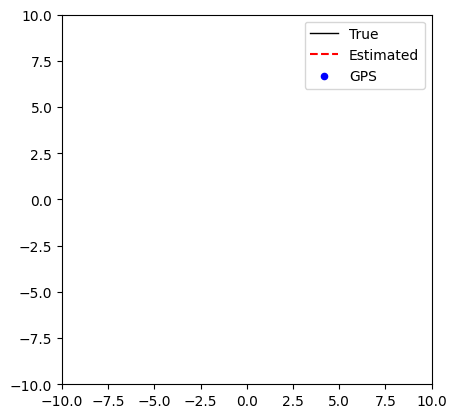

In [136]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

true_line, = ax.plot([], [], 'k-', linewidth=1, label='True')
est_line, = ax.plot([], [], 'r--', label='Estimated')
gps_scatter = ax.scatter([], [], c='b', s=20, label='GPS')

ax.legend()
print("Base Plot")

In [137]:
def update(i):
    ax.clear()
    ax.set_aspect('equal')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)

    # trajectories
    true_xy = np.array(x_true_hist[:i+1])
    est_xy = np.array(x_est_hist[:i+1])

    ax.plot(true_xy[:, 0], true_xy[:, 1], 'k-', linewidth=1, label='True')
    ax.plot(est_xy[:, 0], est_xy[:, 1], 'r--', label='Estimated')

    # GPS points (only when available)
    gps_points = [g for g in gps_hist[:i+1] if g is not None]
    if len(gps_points) > 0:
        gps_xy = np.array(gps_points)
        ax.scatter(gps_xy[:, 0], gps_xy[:, 1], c='b', s=20, label='GPS')

    # covariance ellipse at current step
    plot_covariance_ellipse(ax, x_est_hist[i], P_hist[i])

    ax.legend()

In [138]:
x_true_hist = []
x_est_hist = []
P_hist = []
gps_hist = []

In [26]:
dt = 0.1
T = 35.0
N = int(T / dt)

# parameters
v_nom = 2.0
omega_turn = 0.4
T_lobe = 2 * np.pi / omega_turn
T_fig8 = 2 * T_lobe

sigma_v = 1.0
sigma_omega = 0.05
sigma_GPS = 0.3

gps_rate = int(1 / dt)

# initial conditions
x_true = np.array([0.0, 0.0, 0.0])
x_est = np.array([0.0, 0.0, 0.0])
P = 0.01 * np.eye(3)

# history
x_true_hist = []
x_est_hist = []
P_hist = []
gps_hist = []
nees_hist = []
nis_hist = []

def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def exact_unicycle_step(state, v_cmd, omega_cmd, dt):
    x, y, theta = np.asarray(state, dtype=float)
    phi = omega_cmd * dt
    travel = dt * v_cmd * np.sinc(phi / (2.0 * np.pi))
    theta_mid = theta + 0.5 * phi
    return np.array([
        x + travel * np.cos(theta_mid),
        y + travel * np.sin(theta_mid),
        theta + phi
    ], dtype=float)

def omega_ref(t):
    tau = t % T_fig8
    if tau < T_lobe:
        return omega_turn
    else:
        return -omega_turn

In [ ]:
for k in range(N):
    t = k * dt

    # commanded input
    u = [v_nom, omega_ref(t)]

    # --- True system ---
    w_v = np.random.randn() * sigma_v
    w_omega = np.random.randn() * sigma_omega

    x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
    x_true[2] = wrap_angle(x_true[2])

    # --- GPS measurement ---
    if k % gps_rate == 0:
        v_meas = np.random.randn(2) * sigma_GPS
        y = x_true[:2] + v_meas
    else:
        y = None

    # --- Predict ---
    x_pred, P_pred = ekf_predict(x_est, P, dt, u, sigma_v, sigma_omega)
    x_pred[2] = wrap_angle(x_pred[2])

    # --- NIS ---
    if y is not None:
        H_gps = np.array([
            [1, 0, 0],
            [0, 1, 0]
        ])
        R_gps = sigma_GPS**2 * np.eye(2)

        innovation = y - H_gps @ x_pred
        S = H_gps @ P_pred @ H_gps.T + R_gps
        nis = innovation.T @ np.linalg.inv(S) @ innovation
    else:
        nis = np.nan

    # --- Correct ---
    if y is not None:
        x_est, P = ekf_correct(x_pred, P_pred, y, sigma_GPS)
        x_est[2] = wrap_angle(x_est[2])
    else:
        x_est, P = x_pred, P_pred

    # --- NEES ---
    err = x_true - x_est
    err[2] = wrap_angle(err[2])
    nees = err.T @ np.linalg.inv(P) @ err

    # --- Store ---
    x_true_hist.append(x_true.copy())
    x_est_hist.append(x_est.copy())
    P_hist.append(P.copy())
    gps_hist.append(y)
    nees_hist.append(nees)
    nis_hist.append(nis)

x_true_hist = np.array(x_true_hist)
x_est_hist = np.array(x_est_hist)
P_hist = np.array(P_hist)
nees_hist = np.array(nees_hist)
nis_hist = np.array(nis_hist)

In [140]:
ani = FuncAnimation(fig, update, frames=len(x_est_hist), interval=100)
ani.save('ekf_animation.mp4', fps=10)

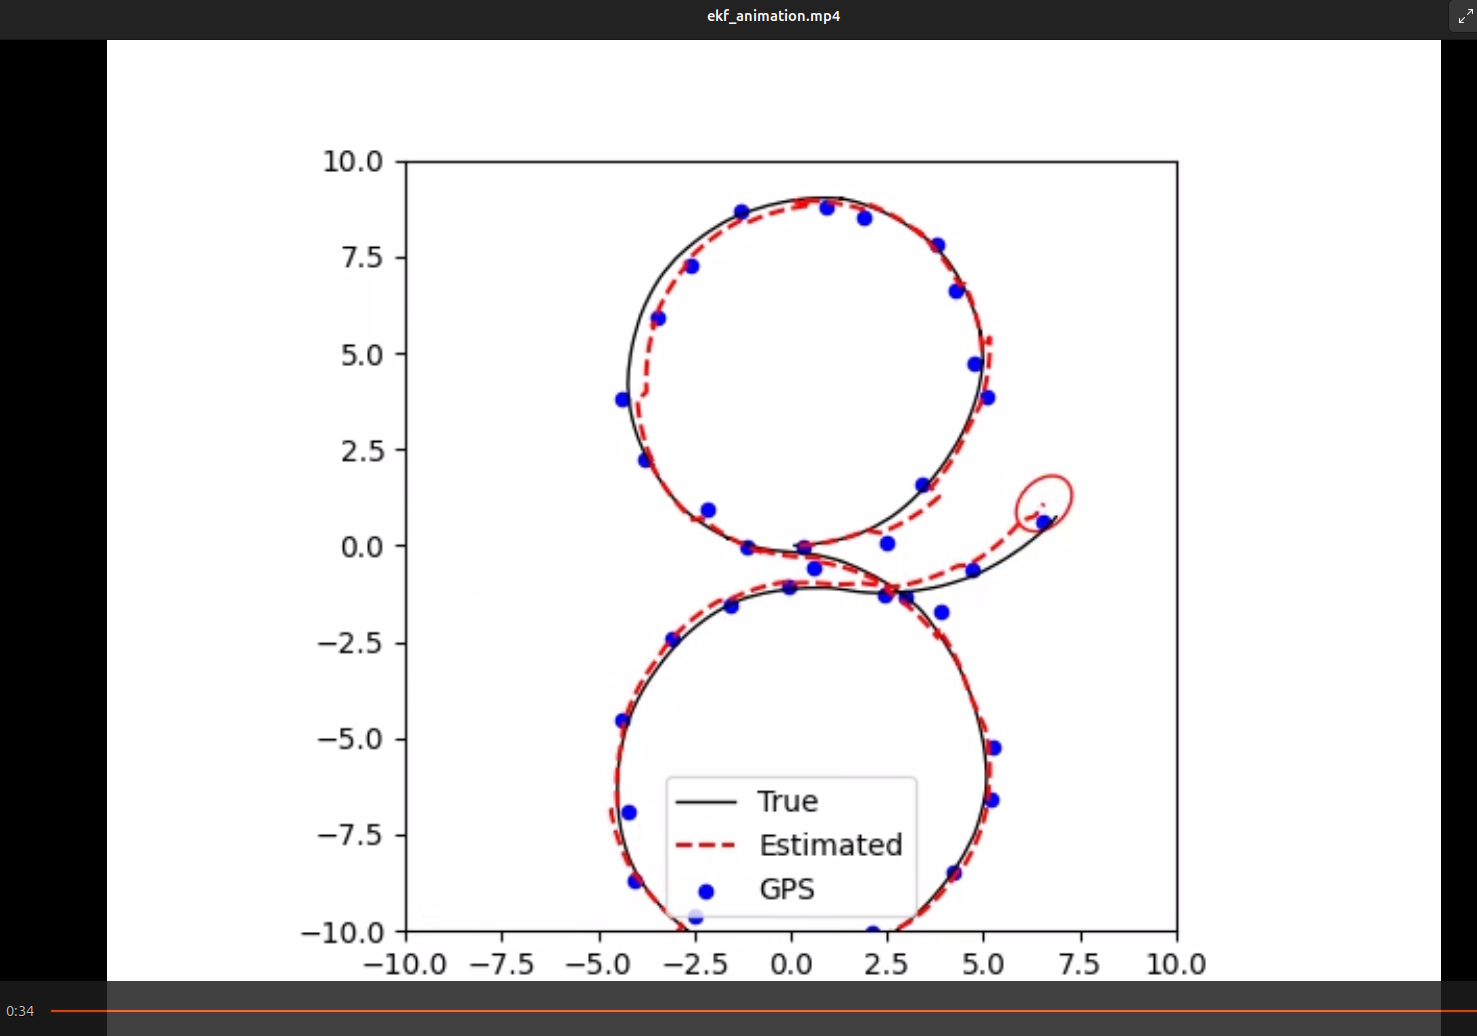

Since this is a world-frame EKF, the process noise covariance is expressed in world coordinates, so its orientation changes with the vehicle heading theta. 

As the vehicle turns, the covariance ellipse rotates accordingly. Because the forward-speed noise sigma_v is much larger than the heading-rate noise sigma_omega, the uncertainty grows primarily along the direction of motion, so the ellipse’s major axis tends to align with the vehicle’s velocity or forward direction.

# 2e. Monte Carlo Evaluation

In [27]:
# initial conditions
x_true = np.array([0.0, 0.0, 0.0])
x_est = np.array([0.0, 0.0, 0.0])
P = 0.01 * np.eye(3)

# history
x_true_hist = []
x_est_hist = []
P_hist = []
gps_hist = []
nees_hist = []
nis_hist = []

In [30]:
M = 100
nx = 3
nz = 2

nees_all = np.zeros((M, N))
nis_all = np.full((M, N), np.nan)

for m in range(M):
    x_true = np.array([0.0, 0.0, 0.0])
    x_est = np.array([0.0, 0.0, 0.0])
    P = 0.01 * np.eye(3)

    nees_hist = []
    nis_hist = []

    for k in range(N):
        t = k * dt
        u = [v_nom, omega_ref(t)]

        # true system
        w_v = np.random.randn() * sigma_v
        w_omega = np.random.randn() * sigma_omega

        x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
        x_true[2] = wrap_angle(x_true[2])

        # measurement
        if k % gps_rate == 0:
            v = np.random.randn(2) * sigma_GPS
            y = x_true[:2] + v
        else:
            y = None

        # predict
        x_pred, P_pred = ekf_predict(x_est, P, dt, u, sigma_v, sigma_omega)
        x_pred[2] = wrap_angle(x_pred[2])

        # NIS
        if y is not None:
            H = np.array([
                [1, 0, 0],
                [0, 1, 0]
            ])
            R = sigma_GPS**2 * np.eye(2)

            innovation = y - H @ x_pred
            S = H @ P_pred @ H.T + R
            nis = innovation.T @ np.linalg.inv(S) @ innovation
        else:
            nis = np.nan

        # correct
        if y is not None:
            x_est, P = ekf_correct(x_pred, P_pred, y, sigma_GPS)
            x_est[2] = wrap_angle(x_est[2])
        else:
            x_est, P = x_pred, P_pred

        # NEES
        err = x_true - x_est
        err[2] = wrap_angle(err[2])
        nees = err.T @ np.linalg.inv(P) @ err

        nees_hist.append(nees)
        nis_hist.append(nis)

    nees_all[m, :] = np.array(nees_hist)
    nis_all[m, :] = np.array(nis_hist)

/tmp/ipykernel_4968/2144570986.py:2: RuntimeWarning: Mean of empty slice
  nis_avg = np.nanmean(nis_all, axis=0)


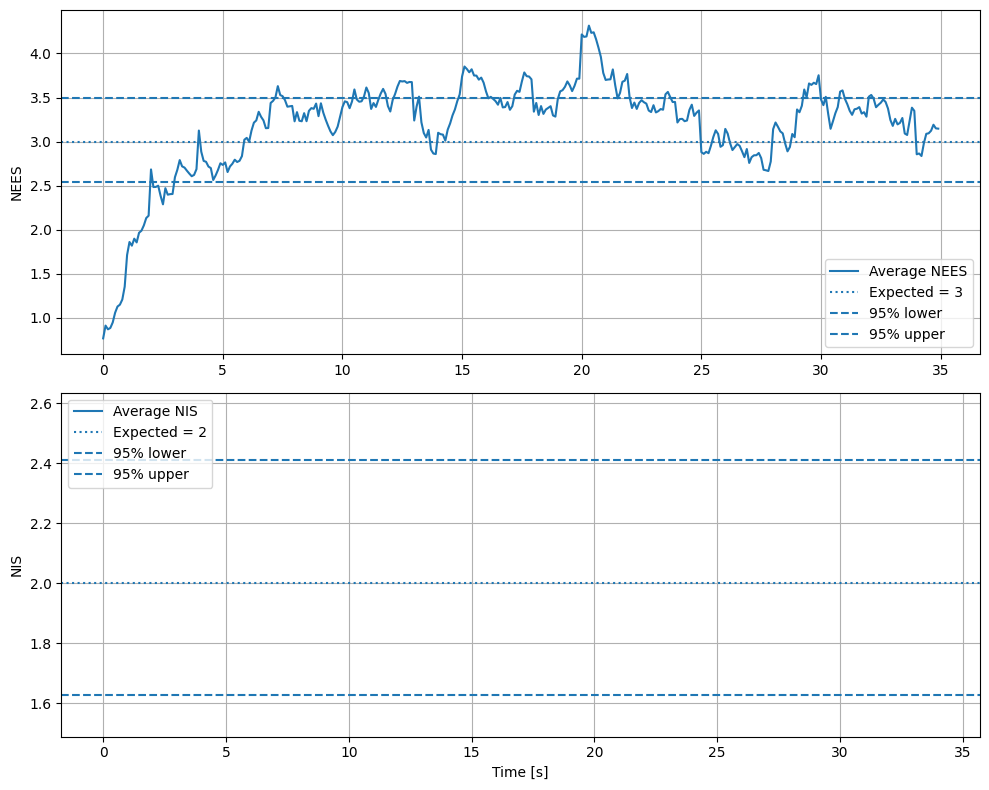

In [31]:
nees_avg = np.mean(nees_all, axis=0)
nis_avg = np.nanmean(nis_all, axis=0)

nees_lo = chi2.ppf(0.025, M * nx) / M
nees_hi = chi2.ppf(0.975, M * nx) / M

nis_lo = chi2.ppf(0.025, M * nz) / M
nis_hi = chi2.ppf(0.975, M * nz) / M

t_arr = np.arange(N) * dt

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t_arr, nees_avg, label='Average NEES')
plt.axhline(nx, linestyle=':', label='Expected = 3')
plt.axhline(nees_lo, linestyle='--', label='95% lower')
plt.axhline(nees_hi, linestyle='--', label='95% upper')
plt.ylabel('NEES')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_arr, nis_avg, label='Average NIS')
plt.axhline(nz, linestyle=':', label='Expected = 2')
plt.axhline(nis_lo, linestyle='--', label='95% lower')
plt.axhline(nis_hi, linestyle='--', label='95% upper')
plt.ylabel('NIS')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()